# Part 2 — Exploratory Data Analysis (EDA)

## What is this notebook about?

Now that our data is clean, we need to **explore and understand it** before jumping into modeling. This step is called EDA (Exploratory Data Analysis) and it is one of the most important parts of any data science project.

The goal is simple: look at the data from every angle, find patterns, and understand how the different variables relate to each other. Everything we discover here will help us make better decisions when we build our models, and will also help us tell a clear story in our final report.

In this notebook we will:
- Look at the **price evolution** of each sector over time
- Analyze the **distribution of returns** across sectors
- Study the **volatility patterns** over time
- Explore the **correlations** between sectors
- Understand the relationship between **macro indicators and stock returns**


## Step 0 — Load the Data

We start by loading the clean dataset we saved at the end of notebook 01.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
os.makedirs('plots', exist_ok=True)

# Load the clean dataset from notebook 01
master_df = pd.read_parquet('data/01_master_data.parquet')
macro_df  = pd.read_parquet('data/01_macro_data.parquet')

print('Dataset loaded successfully!')
print(f'  Shape   : {master_df.shape}')
print(f'  Dates   : {master_df["date"].min().date()} to {master_df["date"].max().date()}')
print(f'  Stocks  : {master_df["ticker"].nunique()}')
print(f'  Sectors : {list(master_df["sector"].unique())}')
print()
master_df.head(3)

Dataset loaded successfully!
  Shape   : (76146, 14)
  Dates   : 2020-01-02 to 2026-03-10
  Stocks  : 49
  Sectors : ['Technology', 'Healthcare', 'Finance', 'Industrials', 'Energy']



,date,ticker,sector,close,open,high,low,volume,return,VIX,RATE_10Y,SP500,OIL,DXY
0,2020-01-02,AAPL,Technology,72.400528,71.409793,72.460791,71.156689,135480400,-0.009722,61.180000,96.849998,3257.850098,1.882,12.47
1,2020-01-03,AAPL,Technology,71.696632,71.629138,72.455950,71.472454,146322800,-0.009722,63.049999,96.839996,3234.850098,1.788,14.02
2,2020-01-06,AAPL,Technology,72.267952,70.819223,72.306521,70.568525,118387200,0.007969,63.270000,96.669998,3246.280029,1.811,13.85



## Step 1 — Sector Performance Over Time

The first thing we want to understand is how each sector evolved since 2020. To compare sectors fairly, we **normalize all prices to 100 at the start** — this way we can compare sectors that have very different price levels on the same chart.

This chart will show us:
- Which sectors recovered fastest after the COVID crash of March 2020
- Which sectors benefited most from the AI boom in 2023
- Which sectors are more defensive (less affected by market crashes)

We also mark the 3 key market events that happened during our period:
- **COVID crash** (March 2020)
- **Fed rate hikes** (January 2022)
- **AI boom** (January 2023)

In [2]:
# Pivot to wide format to compute normalized prices
close_wide = master_df.pivot(index='date', columns='ticker', values='close')

# Normalize each stock to 100 at the first available date
# Formula: normalized = (price / first_price) * 100
close_norm = close_wide.div(close_wide.iloc[0]) * 100

# Compute the average normalized price per sector
sector_lookup = master_df[['ticker', 'sector']].drop_duplicates().set_index('ticker')['sector']
sector_avg    = {}

for sector in master_df['sector'].unique():
    tickers_in_sector = sector_lookup[sector_lookup == sector].index.tolist()
    tickers_available = [t for t in tickers_in_sector if t in close_norm.columns]
    sector_avg[sector] = close_norm[tickers_available].mean(axis=1)

sector_perf_df = pd.DataFrame(sector_avg)

print('Normalized sector performance computed!')
print(f'  Final values (base = 100 at start):')
print(sector_perf_df.iloc[-1].round(1).sort_values(ascending=False))

Normalized sector performance computed!
  Final values (base = 100 at start):
Technology     549.2
Industrials    263.9
Finance        238.8
Healthcare     231.6
Energy         230.7
Name: 2026-03-10 00:00:00, dtype: float64


Now let's visualize this on a chart. We add markers for the 3 key market events so we can clearly see how each sector reacted to them.

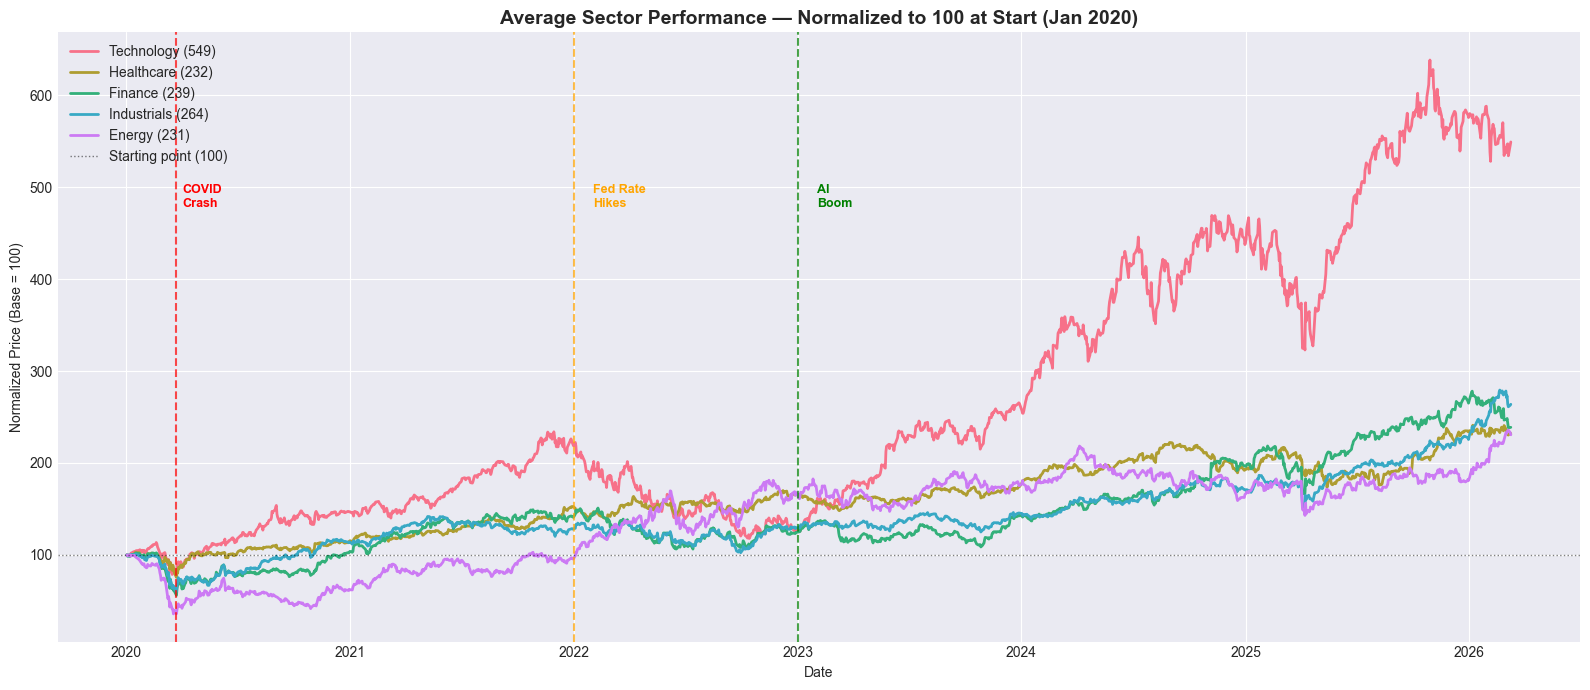

Plot saved: plots/04_sector_performance.png


In [3]:
fig, ax = plt.subplots(figsize=(16, 7))
colors  = sns.color_palette('husl', len(sector_perf_df.columns))

for i, sector in enumerate(sector_perf_df.columns):
    ax.plot(sector_perf_df.index, sector_perf_df[sector],
            label=f'{sector} ({sector_perf_df[sector].iloc[-1]:.0f})',
            linewidth=2, color=colors[i])

# Mark key market events
ymax = sector_perf_df.max().max()

ax.axvline(pd.Timestamp('2020-03-23'), color='red', linestyle='--', alpha=0.7, linewidth=1.5)
ax.text(pd.Timestamp('2020-04-01'), ymax * 0.75, 'COVID\nCrash', color='red', fontsize=9, fontweight='bold')

ax.axvline(pd.Timestamp('2022-01-01'), color='orange', linestyle='--', alpha=0.7, linewidth=1.5)
ax.text(pd.Timestamp('2022-02-01'), ymax * 0.75, 'Fed Rate\nHikes', color='orange', fontsize=9, fontweight='bold')

ax.axvline(pd.Timestamp('2023-01-01'), color='green', linestyle='--', alpha=0.7, linewidth=1.5)
ax.text(pd.Timestamp('2023-02-01'), ymax * 0.75, 'AI\nBoom', color='green', fontsize=9, fontweight='bold')

ax.axhline(100, color='black', linestyle=':', linewidth=1, alpha=0.5, label='Starting point (100)')
ax.set_title('Average Sector Performance — Normalized to 100 at Start (Jan 2020)', fontsize=14, fontweight='bold')
ax.set_ylabel('Normalized Price (Base = 100)')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('plots/04_sector_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: plots/04_sector_performance.png')


## Step 2 — Return Distribution by Sector

Now we look at the **distribution of daily returns** for each sector. This tells us how often each sector has large positive or negative days, and how spread out the returns are.

What we are looking for:
- **Width of the distribution**: a wide distribution means high volatility — more risk but also more potential reward
- **Symmetry**: is the distribution balanced or tilted toward one side?
- **Fat tails**: are there more extreme values than expected? This is a well-known property of financial returns

This analysis also confirms why we applied winsorization in notebook 01 — extreme values are a real characteristic of financial data and not just random noise.

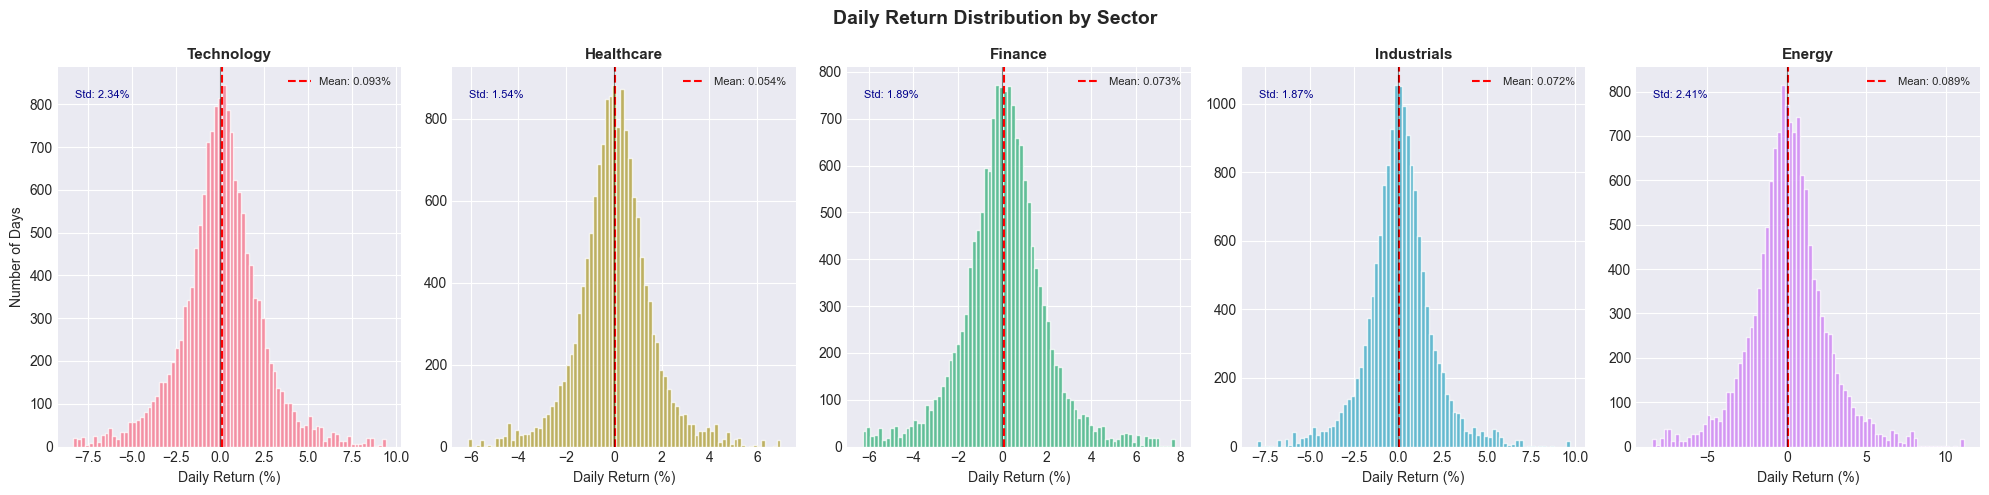

Plot saved: plots/05_return_distributions.png


In [4]:
sectors = list(master_df['sector'].unique())
colors  = sns.color_palette('husl', len(sectors))

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, sector in enumerate(sectors):
    sector_returns = master_df[master_df['sector'] == sector]['return'] * 100

    axes[i].hist(sector_returns.dropna(), bins=80, color=colors[i], alpha=0.75, edgecolor='white')
    axes[i].axvline(sector_returns.mean(), color='red', linestyle='--', linewidth=1.5,
                    label=f'Mean: {sector_returns.mean():.3f}%')
    axes[i].axvline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    axes[i].set_title(sector, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Daily Return (%)')
    axes[i].legend(fontsize=8)

    # Show std on the chart
    std = sector_returns.std()
    axes[i].text(0.05, 0.92, f'Std: {std:.2f}%',
                 transform=axes[i].transAxes, fontsize=8, color='darkblue')

axes[0].set_ylabel('Number of Days')
plt.suptitle('Daily Return Distribution by Sector', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05_return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: plots/05_return_distributions.png')


## Step 3 — Volatility Over Time

Volatility measures how much prices move around. In finance, volatility is often used as a proxy for **risk**. A high-volatility period means prices are moving a lot in both directions — this makes prediction harder but also more interesting for our model.

We compute a **rolling 30-day volatility** for each sector: at each point in time, we look at the standard deviation of returns over the past 30 days. This gives us a smooth picture of how risky the market has been recently.

This is important for our project because we want to check whether our model performs consistently across different volatility regimes — calm periods versus crisis periods.

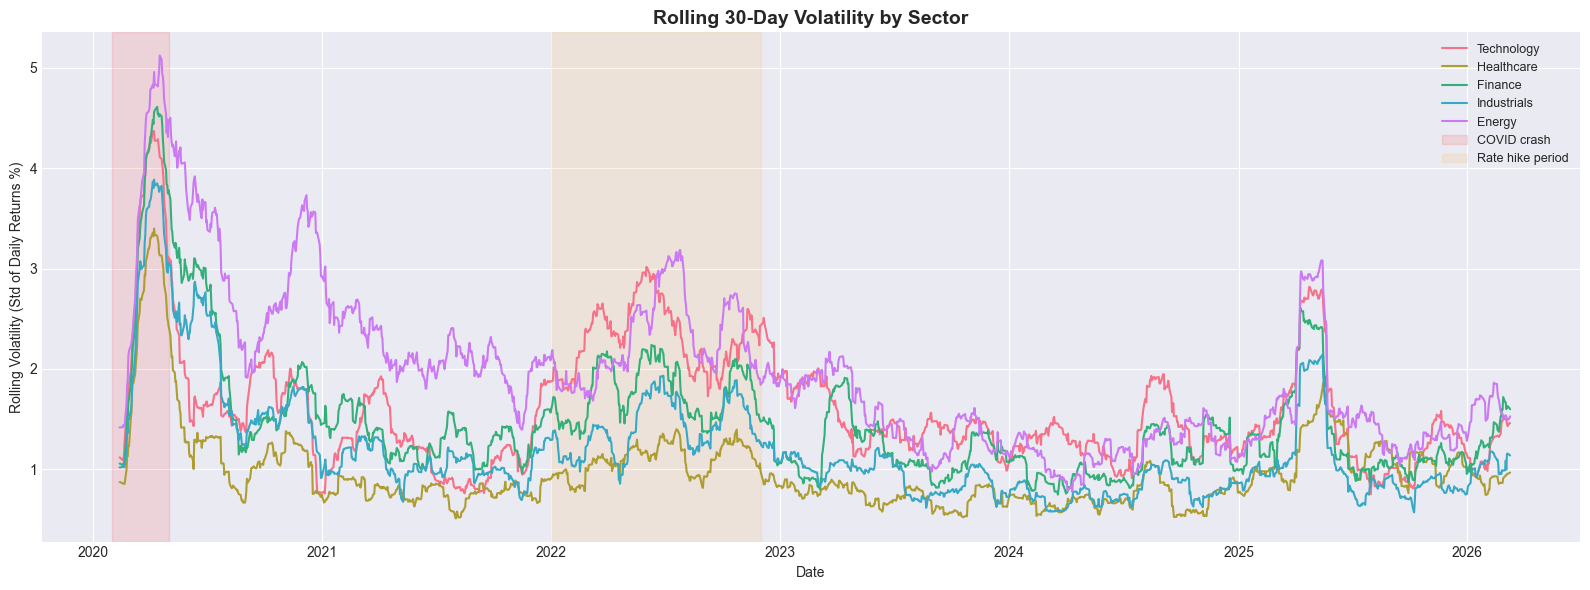

Plot saved: plots/06_rolling_volatility.png


In [5]:
fig, ax = plt.subplots(figsize=(16, 6))
colors  = sns.color_palette('husl', len(sectors))

for i, sector in enumerate(sectors):
    # Average daily return across all stocks in the sector
    sector_data = master_df[master_df['sector'] == sector].groupby('date')['return'].mean()
    # Rolling 30-day standard deviation = volatility
    rolling_vol = sector_data.rolling(window=30).std() * 100

    ax.plot(rolling_vol.index, rolling_vol.values,
            label=sector, linewidth=1.5, color=colors[i])

# Highlight key market periods
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-05-01'),
           alpha=0.1, color='red', label='COVID crash')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-01'),
           alpha=0.1, color='orange', label='Rate hike period')

ax.set_title('Rolling 30-Day Volatility by Sector', fontsize=14, fontweight='bold')
ax.set_ylabel('Rolling Volatility (Std of Daily Returns %)')
ax.set_xlabel('Date')
ax.legend(loc='upper right', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('plots/06_rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: plots/06_rolling_volatility.png')


## Step 4 — Correlation Between Sectors

Now we look at how correlated the different sectors are with each other. This is important for two reasons:

1. **For our model**: if all sectors move together all the time, there is no real difference between them and our multi-sector approach adds little value. If they are weakly correlated, it means each sector has its own dynamics and the model needs to learn different patterns for each one.

2. **For our project justification**: low correlation between sectors is exactly what makes our generalization question interesting — can a single model handle sectors that behave differently?

We compute the correlation on the **average daily return per sector** — we first average all returns within a sector for each day, then correlate the resulting series.

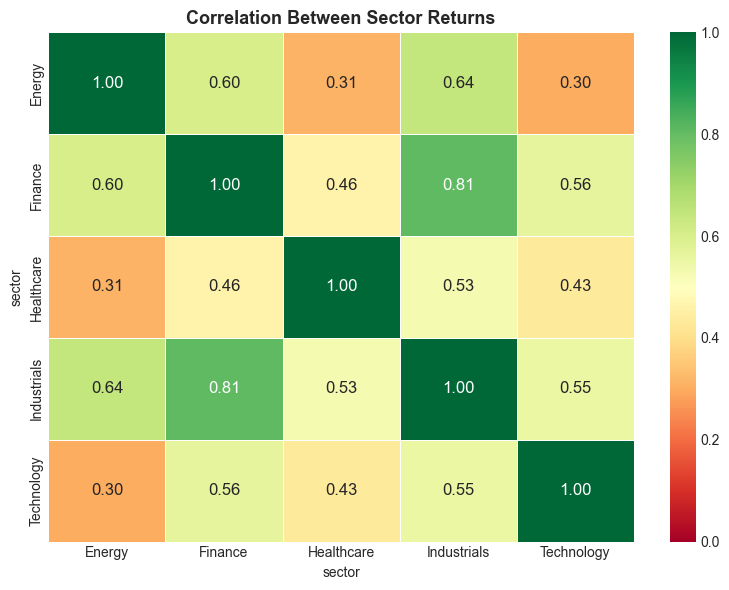

Correlation matrix:
sector       Energy  Finance  Healthcare  Industrials  Technology
sector                                                           
Energy         1.00     0.60        0.31         0.64        0.30
Finance        0.60     1.00        0.46         0.81        0.56
Healthcare     0.31     0.46        1.00         0.53        0.43
Industrials    0.64     0.81        0.53         1.00        0.55
Technology     0.30     0.56        0.43         0.55        1.00

Interpretation:
  Close to 1.0 → sectors move together
  Close to 0.0 → sectors move independently


In [6]:
# Compute average daily return per sector
sector_returns_daily = master_df.groupby(['date', 'sector'])['return'].mean().unstack('sector')

# Compute the correlation matrix between sectors
corr_matrix = sector_returns_daily.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=0, vmax=1,
    center=0.5,
    ax=ax,
    linewidths=0.5,
    annot_kws={'size': 12}
)
ax.set_title('Correlation Between Sector Returns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/07_sector_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation matrix:')
print(corr_matrix.round(2))
print()
print('Interpretation:')
print('  Close to 1.0 → sectors move together')
print('  Close to 0.0 → sectors move independently')


## Step 5 — Macro Indicators vs Sector Returns

This is one of the most interesting parts of the EDA. We want to understand how the macroeconomic indicators we collected (VIX, interest rates, oil, dollar) relate to stock returns across different sectors.

This analysis directly justifies our decision to include macro data as features in our model. If there is a clear relationship between a rising VIX and falling stock returns for example, then the VIX will be a useful predictor.

We compute the **correlation between each macro indicator and the average return of each sector**. A strong negative correlation between VIX and Tech returns would mean that when fear spikes, tech stocks tend to fall.

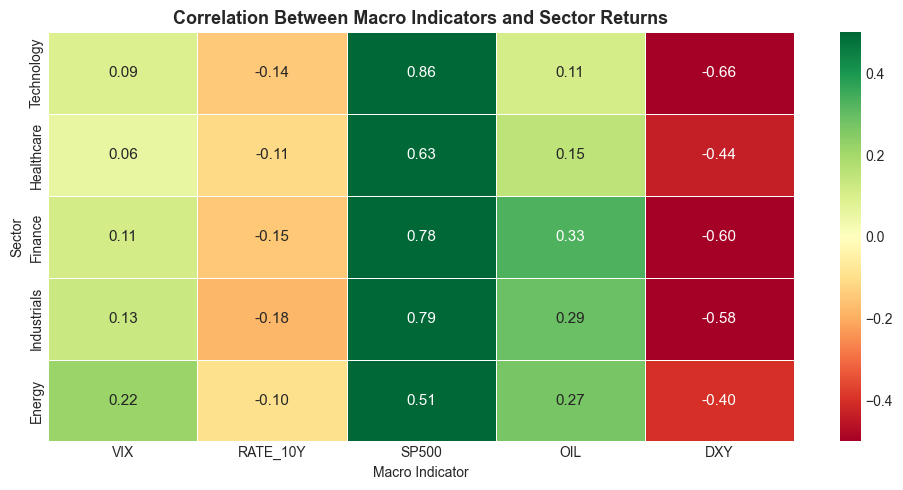

Correlation values:
              VIX  RATE_10Y  SP500   OIL   DXY
Technology   0.09     -0.14   0.86  0.11 -0.66
Healthcare   0.06     -0.11   0.63  0.15 -0.44
Finance      0.11     -0.15   0.78  0.33 -0.60
Industrials  0.13     -0.18   0.79  0.29 -0.58
Energy       0.22     -0.10   0.51  0.27 -0.40


In [8]:
# Average daily return per sector
sector_avg_returns = master_df.groupby(['date', 'sector'])['return'].mean().unstack('sector')

# Compute daily percentage changes for macro indicators
# We use pct_change to keep macro data stationary (same logic as stock returns)
macro_changes = macro_df.pct_change().dropna()

# Align the two DataFrames on the same dates
combined = sector_avg_returns.join(macro_changes, how='inner').dropna()

# Compute correlation between each macro indicator and each sector
macro_cols  = list(macro_df.columns)
sector_cols = list(master_df['sector'].unique())

corr_data = {}
for macro in macro_cols:
    corr_data[macro] = {}
    for sector in sector_cols:
        corr_data[macro][sector] = combined[sector].corr(combined[macro])

corr_macro_df = pd.DataFrame(corr_data)

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    corr_macro_df,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=-0.5, vmax=0.5,
    center=0,
    ax=ax,
    linewidths=0.5,
    annot_kws={'size': 11}
)
ax.set_title('Correlation Between Macro Indicators and Sector Returns', fontsize=13, fontweight='bold')
ax.set_xlabel('Macro Indicator')
ax.set_ylabel('Sector')
plt.tight_layout()
plt.savefig('plots/08_macro_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation values:')
print(corr_macro_df.round(2))

Ca c'est juste pour t'aider toi pour le rapport 


Très riches comme résultats ! Voici l'interprétation pour le rapport :
S&P500 (corrélation très forte, positive)
Tous les secteurs bougent fortement avec le marché global. La Tech est la plus corrélée (0.86) — quand le marché monte, la Tech monte encore plus fort.
Dollar Index DXY (corrélation forte, négative)
C'est le résultat le plus intéressant. Quand le dollar se renforce, tous les secteurs baissent. La Tech est la plus touchée (-0.66) car ses géants (Apple, Google, Microsoft) font une grande partie de leurs revenus à l'international.
Taux d'intérêt RATE_10Y (corrélation négative)
Quand les taux montent, tous les secteurs baissent légèrement. La Tech et la Finance sont les plus sensibles (-0.14, -0.15).
Pétrole OIL
Sans surprise, l'Energy est la plus corrélée au pétrole (0.27). La Finance aussi (0.33) car les grandes banques financent beaucoup de projets énergétiques.
VIX (corrélation faible)
Le VIX est peu corrélé directement aux rendements journaliers — son effet est plutôt visible sur la volatilité que sur la direction.

Ces résultats justifient parfaitement l'inclusion des données macro dans notre modèle, surtout le S&P500 et le DXY qui ont des corrélations très fortes.
On termine le notebook avec la cellule de résumé !
hurt stocks — confirmed by the 2022 period in our data |




## Summary — Key Findings from the EDA

Here is what we learned from exploring the data:

| Finding | Implication for modeling |
|---|---|
| **Technology multiplied by 5.5x since 2020** | The strongest trends are in Tech — the model may find clearer patterns there |
| **COVID crash spiked volatility across all sectors** | The VIX and macro features will help the model detect crisis periods |
| **Finance & Industrials are highly correlated (0.81)** | These two sectors share similar dynamics — economic cycles |
| **Energy & Technology are weakly correlated (0.30)** | Each sector has its own dynamics — our global model needs the sector feature to differentiate them |
| **S&P500 is strongly correlated with all sectors** | The market direction is the strongest predictor — including SP500 as a feature is very important |
| **Dollar index (DXY) strongly negative for all sectors** | A strong dollar hurts all stocks — especially Tech (-0.66) |
| **Interest rates negatively correlated with returns** | Rate hikes hurt stocks — confirmed by the 2022 period in our data |

